In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ML training code/cgpa_package_placement.csv')
df.head()
print(df.info())
print(df.describe)

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None
<bound method NDFrame.describe of      cgpa  package
0    6.89     3.26
1    5.12     1.98
2    7.82     3.25
3    7.42     3.67
4    6.94     3.57
..    ...      ...
195  6.93     2.46
196  5.89     2.57
197  7.21     3.24
198  7.63     3.96
199  6.22     2.33

[200 rows x 2 columns]>


In [16]:
X = df['cgpa']           # ← DataFrame (n_rows, 1) // we need (100,1) format in shape, its the requirement of sklearn
y = df['package']          # Series

In [17]:
X.shape

(200,)

In [18]:
y.shape

(200,)

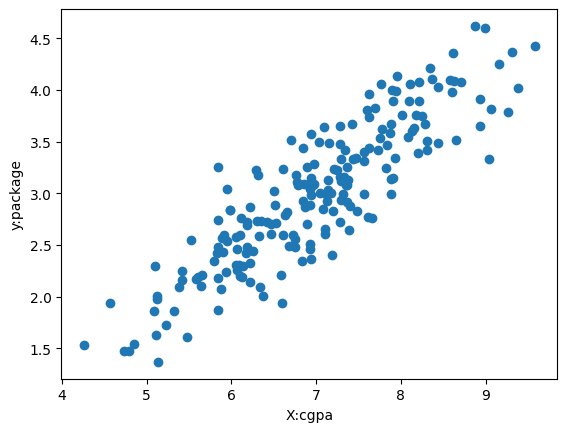

In [19]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.xlabel('X:cgpa')
plt.ylabel('y:package')
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [22]:
X_train

,cgpa
137,7.14
110,8.18
7,6.75
181,8.22
65,7.60
...,...
22,6.14
63,9.16
92,7.90
33,6.35


In [23]:
X_test

,cgpa
124,6.06
24,6.53
150,6.30
35,6.87
30,7.36
148,7.57
195,6.93
139,7.19
120,5.23
115,8.35


In [24]:
X_train.shape

(160, 1)

In [25]:
X_test.shape

(40, 1)

In [67]:

def fit():
  x_sum = 0
  x_mean = 0
  y_sum = 0
  y_mean = 0
  m_numerator = 0
  m_denominator = 0
  #
  # b = (y_bar - m*x_bar)
  # m = summ.(x-x_bar)(y-y_bar)/summ.(x-x_bar)^2
  for i in range(len(X_train)):
    x_sum += X[i];
    x_mean = x_sum/len(X_train)
    y_sum += y[i];
    y_mean = y_sum/len(y_train)


 # print(x_mean,y_mean)
 # print(X.mean(),y.mean())

  for i in range(len(X_train)):
    m_numerator += (X[i]-x_mean)*(y[i]-y_mean)
    m_denominator += (X[i]-x_mean)**2

  m = m_numerator/m_denominator
  b = y_mean - m*x_mean
 # print(m,b)
  return m,b



In [84]:
def predict(m,b,X_test):
  y_pred = []
  for i in range(len(X_test)):
    y_pred.append(m*X_test[i]+b)
  return y_pred




In [88]:

m,b = fit()
#print(m,b)
y_pred = predict(m,b,X_test.values.reshape(-1))
#X_test.values.reshape(-1)
pd.DataFrame({'cgpa':X_test.values.reshape(-1), 'Actual_Package':y_test.values.reshape(-1),'Predicted_package':y_pred})
new_ypred = predict(m,b,[9.38])
print(new_ypred)

[np.float64(4.3711158599784)]


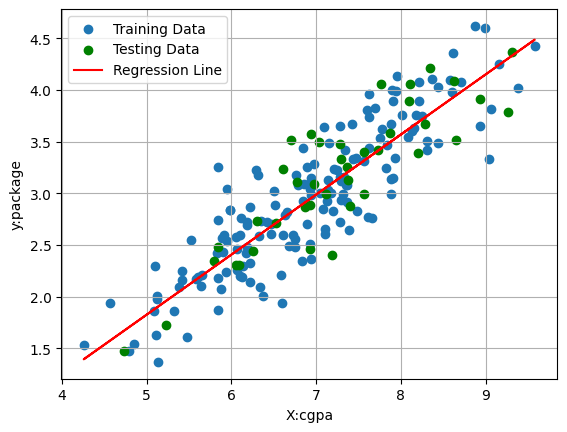

In [94]:
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train)
plt.scatter(X_test,y_test,color="green")
plt.plot(X_train,m*X_train+b,color='red')
plt.legend(['Training Data','Testing Data','Regression Line'])
plt.xlabel('X:cgpa')
plt.ylabel('y:package')
plt.grid()
plt.show()